# 2 AG News (topic, 4 classes)

### Setup and Import Libraries

In [1]:
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load the dataset

In [2]:
url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
df = pd.read_csv(url, header=None, names=["label", "title", "desc"])

# Use a subset for faster training (remove this line to use all 120k rows)
df = df.sample(n=30000, random_state=SEED).reset_index(drop=True)

df["text"] = (df["title"] + " " + df["desc"]).astype(str)
df["label"] = df["label"] - 1  # shift 1-4 -> 0-3

print(df[["label", "text"]].head())
print("Shape:", df.shape)
print("Class distribution:\n", df["label"].value_counts())

   label                                               text
0      2  BBC set for major shake-up, claims newspaper L...
1      2  Marsh averts cash crunch Embattled insurance b...
2      1  Jeter, Yankees Look to Take Control (AP) AP - ...
3      3  Flying the Sun to Safety When the Genesis caps...
4      2  Stocks Seen Flat as Nortel and Oil Weigh  NEW ...
Shape: (30000, 4)
Class distribution:
 label
1    7560
3    7528
0    7472
2    7440
Name: count, dtype: int64


### Clean and tokenize

In [3]:
def clean_text(s):
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text"] = df["text"].apply(clean_text)
df["tokens"] = df["text"].apply(str.split)
df[["text", "tokens"]].head()

,text,tokens
0,bbc set for major shake up claims newspaper lo...,"[bbc, set, for, major, shake, up, claims, news..."
1,marsh averts cash crunch embattled insurance b...,"[marsh, averts, cash, crunch, embattled, insur..."
2,jeter yankees look to take control ap ap derek...,"[jeter, yankees, look, to, take, control, ap, ..."
3,flying the sun to safety when the genesis caps...,"[flying, the, sun, to, safety, when, the, gene..."
4,stocks seen flat as nortel and oil weigh new y...,"[stocks, seen, flat, as, nortel, and, oil, wei..."


### Build Vocab

In [4]:
from collections import Counter

MAXLEN = 40
VOCAB_SIZE = 20000

counter = Counter()
for toks in df["tokens"]:
    counter.update(toks)

most_common = counter.most_common(VOCAB_SIZE - 2)  # reserve 0=PAD, 1=UNK
word2idx = {"<PAD>": 0, "<UNK>": 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

print("Vocab size:", len(word2idx))

Vocab size: 20000


### Encode text to fixed-length ID sequences

In [5]:
def encode(tokens, maxlen=MAXLEN):
    ids = [word2idx.get(t, 1) for t in tokens[:maxlen]]
    ids = ids + [0] * (maxlen - len(ids))
    return ids

df["ids"] = df["tokens"].apply(lambda t: encode(t))

X = np.stack(df["ids"].values)
y = df["label"].values

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (30000, 40) y shape: (30000,)


### Fixed 80/20 split

In [6]:
n = len(X)
idx = np.arange(n)
rng = np.random.RandomState(SEED)
rng.shuffle(idx)

split = int(0.8 * n)
train_idx, test_idx = idx[:split], idx[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")

Train size: 24000  Test size: 6000


### Dataset and DataLoader

In [7]:
class AGNewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_ds = AGNewsDataset(X_train, y_train)
test_ds = AGNewsDataset(X_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

### Model Definition

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=4, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                # (batch, seq_len, embed_dim)
        _, (h_n, _) = self.lstm(emb)            # h_n: (1, batch, hidden_dim)
        out = self.fc(h_n[-1])                  # (batch, num_classes)
        return out

model = LSTMClassifier(vocab_size=len(word2idx)).to(device)
print(model)

LSTMClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


### Training Loop

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 100
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch}/{EPOCHS} - loss: {epoch_loss:.4f}")

Epoch 1/100 - loss: 0.0015
Epoch 2/100 - loss: 0.0053
Epoch 3/100 - loss: 0.0012
Epoch 4/100 - loss: 0.0004
Epoch 5/100 - loss: 0.0003
Epoch 6/100 - loss: 0.0003
Epoch 7/100 - loss: 0.0003
Epoch 8/100 - loss: 0.0003
Epoch 9/100 - loss: 0.0003
Epoch 10/100 - loss: 0.0003
Epoch 11/100 - loss: 0.0003
Epoch 12/100 - loss: 0.0003
Epoch 13/100 - loss: 0.0003
Epoch 14/100 - loss: 0.0002
Epoch 15/100 - loss: 0.0003
Epoch 16/100 - loss: 0.0003
Epoch 17/100 - loss: 0.0003
Epoch 18/100 - loss: 0.0003
Epoch 19/100 - loss: 0.0003
Epoch 20/100 - loss: 0.0003
Epoch 21/100 - loss: 0.0003
Epoch 22/100 - loss: 0.0003
Epoch 23/100 - loss: 0.0003
Epoch 24/100 - loss: 0.0003
Epoch 25/100 - loss: 0.0002
Epoch 26/100 - loss: 0.0147
Epoch 27/100 - loss: 0.0078
Epoch 28/100 - loss: 0.0025
Epoch 29/100 - loss: 0.0007
Epoch 30/100 - loss: 0.0003
Epoch 31/100 - loss: 0.0002
Epoch 32/100 - loss: 0.0002
Epoch 33/100 - loss: 0.0002
Epoch 34/100 - loss: 0.0002
Epoch 35/100 - loss: 0.0002
Epoch 36/100 - loss: 0.0002
E

### Evaluate on test set

In [16]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc*100:.2f}%")
print("Baseline: 25.00% | Target: 88.00%")

Test accuracy: 88.22%
Baseline: 25.00% | Target: 88.00%


### Plot training loss

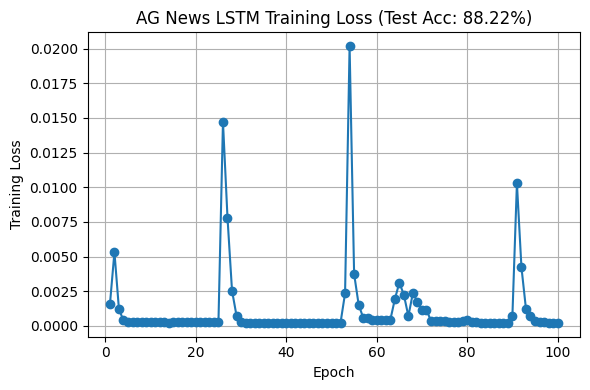

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"AG News LSTM Training Loss (Test Acc: {test_acc*100:.2f}%)")
plt.grid(True)
plt.tight_layout()
plt.show()